# 1. Import and Hardware Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

In [2]:
DATA_PATH = './Data'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 2. Hyperparameter

In [3]:
IMG_SIZE = 256
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

SEED = 42
EPOCHS = 150
LR = 1e-3

AVAILABLE_MODELS = ['MNv4-Conv-S', 'MNv4-Conv-M', 'MNv4-Conv-L', 'MNv4-Hybrid-M', 'MNv4-Hybrid-L']
MODEL_NAME = 'MNv4-Hybrid-M'
if MODEL_NAME not in AVAILABLE_MODELS:
    raise ValueError(f"MODEL_NAME must be one of {AVAILABLE_MODELS}, now: {MODEL_NAME}")
WIDTH_MULTI = 1.0
DROPOUT = 0.2

# 3. Training Data Preparation

In [4]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transforms = transforms.Compose([
    transforms.Resize(288),
    transforms.RandomRotation(15),
    transforms.RandomCrop(IMG_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

test_transforms = transforms.Compose([
    transforms.Resize(288),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

In [5]:
import random
import numpy as np
import os

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.random.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

set_seed(SEED)

In [6]:
# Download full training data as dummy data without transform
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Split the dummy data into two
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

# Extract the indices and create proper subset with correct transform
train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices
train_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=train_transforms
)
val_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=test_transforms
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(
    root=DATA_PATH, split="test", download=True, transform=test_transforms
)

100%|██████████| 5.00G/5.00G [02:59<00:00, 27.8MB/s] 


In [7]:
def seed_worker(worker_id):
    worker_seed = worker_id + SEED
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True,
                          prefetch_factor=2, worker_init_fn=seed_worker, generator=train_generator)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True, persistent_workers=True,
                        prefetch_factor=2, worker_init_fn=seed_worker, generator=eval_generator)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True,
                         prefetch_factor=2, worker_init_fn=seed_worker, generator=eval_generator)

# 4. Model Architecture

In [8]:
def _make_divisible(v, divisor=8, min_value=None):
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


class Conv2dNormActivation(nn.Sequential):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        groups=1,
        activation=nn.ReLU,
    ):
        padding = (kernel_size - 1) // 2
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                groups=groups,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
        ]
        if activation != nn.Identity:
            layers.append(activation(inplace=True))
        super().__init__(*layers)


class FusedIB(nn.Module):
    """
    Fused Inverted Bottleneck Block.
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride, exp_channels):
        super().__init__()
        self.use_res_connect = stride == 1 and in_channels == out_channels

        layers = [
            Conv2dNormActivation(in_channels, exp_channels, kernel_size, stride=stride),
            Conv2dNormActivation(exp_channels, out_channels, 1, activation=nn.Identity),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.block(x)
        return self.block(x)


class UIB(nn.Module):
    """
    Universal Inverted Bottleneck Block.
    Vereint Inverted Bottleneck (IB), ConvNext, FFN und ExtraDW.
    Params:
        dw_k1: Kernel of the Depthwise before Expansion (0 = none)
        dw_k2: Kernel of the Depthwise after Expansion (0 = none)
    """

    def __init__(self, in_channels, out_channels, dw_k1, dw_k2, stride, exp_channels):
        super().__init__()
        self.use_res_connect = stride == 1 and in_channels == out_channels

        layers = []
        # 1. Optional Depthwise bevor the Expansion
        if dw_k1 > 0:
            layers.append(
                Conv2dNormActivation(
                    in_channels, in_channels, dw_k1, stride=stride, groups=in_channels
                )
            )
            stride = 1

        # 2. Pointwise Expansion
        layers.append(Conv2dNormActivation(in_channels, exp_channels, 1))

        # 3. Optional Depthwise after Expansion
        if dw_k2 > 0:
            layers.append(
                Conv2dNormActivation(
                    exp_channels,
                    exp_channels,
                    dw_k2,
                    stride=stride,
                    groups=exp_channels,
                )
            )

        # 4. Pointwise Projection
        layers.append(
            Conv2dNormActivation(exp_channels, out_channels, 1, activation=nn.Identity)
        )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.block(x)
        return self.block(x)


class MobileMQA(nn.Module):
    """
    Optimiertes Mobile MQA Modul mit Einsum-Layout zur Vermeidung von Transponierungen.
    """

    def __init__(self, in_channels, num_heads=8, head_dim=32, sr_ratio=1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.scale = head_dim**-0.5

        # Gewichte für Einsum-Layout optimiert (keine Transposes nötig)
        std_in = in_channels ** -0.5
        self.q_weight = nn.Parameter(torch.randn(in_channels, num_heads, head_dim) * std_in)
        self.k_weight = nn.Parameter(torch.randn(in_channels, head_dim) * std_in)
        self.v_weight = nn.Parameter(torch.randn(in_channels, head_dim) * std_in)
        
        std_out = (num_heads * head_dim) ** -0.5
        self.o_weight = nn.Parameter(torch.randn(num_heads, head_dim, in_channels) * std_out)

        # Asymmetrisches Spatial Downsampling mit stride-2 3x3 Depthwise Conv
        self.sr = nn.Identity()
        if sr_ratio > 1:
            self.sr = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    in_channels,
                    3,
                    stride=sr_ratio,
                    padding=1,
                    groups=in_channels,
                    bias=False,
                ),
                nn.BatchNorm2d(in_channels),
            )

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, -1).permute(0, 2, 1)  # [B, N, C]

        # Q Projektion: bnd, dhk -> bnhk
        q = torch.einsum("bnd, dhk -> bnhk", x_flat, self.q_weight)

        # KV Pfad mit Downsampling
        x_kv = self.sr(x).view(B, C, -1).permute(0, 2, 1)

        # K, V Projektion: bmd, dk -> bmk , bmd, dv -> bmv
        k = torch.einsum("bmd, dk -> bmk", x_kv, self.k_weight)
        v = torch.einsum("bmd, dv -> bmv", x_kv, self.v_weight)

        # Attention: bnhk, bmk -> bnhm
        attn = torch.einsum("bnhk, bmk -> bnhm", q, k) * self.scale
        attn = attn.softmax(dim=-1)

        # Output: bnhm, bmv -> bnhv
        out = torch.einsum("bnhm, bmv -> bnhv", attn, v)

        # Finale Projektion: bnhv, hvd -> bnd
        out = torch.einsum("bnhv, hvd -> bnd", out, self.o_weight)

        # Rückumformung zu [B, C, H, W] und Residualaddierung
        return x + out.permute(0, 2, 1).view(B, C, H, W)


class MobileNetV4(nn.Module):
    def __init__(self, model_name="MNv4-Conv-S", num_classes=1000, dropout=0.2):
        super().__init__()

        configs = {
            "MNv4-Conv-S": [
                ("fused", 3, 0, 32, 32, 2, 1), # FusedIB
                ("fused", 3, 0, 96, 64, 2, 1), # FusedIB
                ("uib", 5, 5, 192, 96, 2, 1), # ExtraDW
                ("uib", 0, 3, 192, 96, 1, 4), # IB
                ("uib", 3, 0, 384, 96, 1, 1), # ConvNext
                ("uib", 3, 3, 576, 128, 2, 1), # ExtraDW
                ("uib", 5, 5, 512, 128, 1, 1), # ExtraDW
                ("uib", 0, 5, 512, 128, 1, 1), # IB
                ("uib", 0, 5, 384, 128, 1, 1), # IB
                ("uib", 0, 3, 512, 128, 1, 2), # IB
            ],
            "MNv4-Conv-M": [
                ("fused", 3, 0, 128, 48, 2, 1), # FusedIB
                ("uib", 3, 5, 192, 80, 2, 1), # ExtraDW
                ("uib", 3, 3, 160, 80, 1, 1), # ExtraDW
                ("uib", 3, 5, 480, 160, 2, 1), # ExtraDW
                ("uib", 3, 3, 640, 160, 1, 2), # ExtraDW
                ("uib", 3, 5, 640, 160, 1, 1), # ExtraDW
                ("uib", 3, 3, 640, 160, 1, 1), # ExtraDW
                ("uib", 3, 0, 640, 160, 1, 1), # ConvNext
                ("uib", 0, 0, 320, 160, 1, 1), # FFN
                ("uib", 3, 0, 640, 160, 1, 1), # ConvNext
                ("uib", 5, 5, 960, 256, 2, 1), # ExtraDW
                ("uib", 5, 5, 1024, 256, 1, 1), # ExtraDW
                ("uib", 3, 5, 1024, 256, 1, 2), # ExtraDW
                ("uib", 0, 0, 1024, 256, 1, 1), # FFN
                ("uib", 3, 0, 1024, 256, 1, 1), # ConvNext
                ("uib", 3, 5, 512, 256, 1, 1), # ExtraDW
                ("uib", 5, 5, 1024, 256, 1, 1), # ExtraDW
                ("uib", 0, 0, 1024, 256, 1, 2), # FFN
                ("uib", 5, 0, 512, 256, 1, 1), # ConvNext
            ],
            "MNv4-Hybrid-M": [
                ("fused", 3, 0, 128, 48, 2, 1), # FusedIB
                ("uib", 3, 5, 192, 80, 2, 1), # ExtraDW
                ("uib", 3, 3, 160, 80, 1, 1), # ExtraDW
                # 160
                ("uib", 3, 5, 480, 160, 2, 1), # # ExtraDW
                ("uib", 3, 3, 640, 160, 1, 2), # ExtraDW
                ("uib", 3, 5, 640, 160, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 160, 1, 1), # MQA
                ("uib", 3, 3, 640, 160, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 160, 1, 1), # MQA
                ("uib", 3, 0, 640, 160, 1, 1), # ConvNext
                ("mqa", 2, 0, 0, 160, 1, 1), # MQA
                ("uib", 0, 0, 640, 160, 1, 1), # FFN
                ("mqa", 2, 0, 0, 160, 1, 1), # MQA
                ("uib", 3, 0, 640, 160, 1, 1), # ConvNext
                # 256
                ("uib", 5, 5, 960, 256, 2, 1), # ExtraDW
                ("uib", 5, 5, 1024, 256, 1, 1), # ExtraDW
                ("uib", 3, 5, 1024, 256, 1, 2), # ExtraDW
                ("uib", 0, 0, 1024, 256, 1, 1), # FFN
                ("uib", 3, 0, 1024, 256, 1, 1), # ConvNext
                ("uib", 3, 5, 512, 256, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 256, 1, 1), # MQA
                ("uib", 5, 5, 1024, 256, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 256, 1, 1), # MQA
                ("uib", 0, 0, 1024, 256, 1, 1), # FFN
                ("mqa", 2, 0, 0, 256, 1, 1), # MQA
                ("uib", 5, 0, 1024, 256, 1, 1), # ConvNext
            ],
            "MNv4-Conv-L": [
                ("fused", 3, 0, 96, 48, 2, 1), # FusedIB
                # 96
                ("uib", 3, 5, 192, 96, 2, 1), # ExtraDW
                ("uib", 3, 3, 384, 96, 1, 1), # ExtraDW
                # 192
                ("uib", 3, 5, 384, 192, 2, 1), # ExtraDW
                ("uib", 3, 3, 768, 192, 1, 3), # ExtraDW
                ("uib", 3, 5, 768, 192, 1, 1), # ExtraDW
                ("uib", 5, 3, 768, 192, 1, 5), # ExtraDW
                ("uib", 3, 3, 768, 192, 1, 1), # ExtraDW
                ("uib", 3, 0, 768, 192, 1, 1), # ConvNext
                # 512
                ("uib", 5, 5, 768, 512, 2, 1), # ExtraDW
                ("uib", 5, 5, 2048, 512, 1, 3), # ExtraDW
                ("uib", 5, 0, 2048, 512, 1, 1), # ConvNext
                ("uib", 5, 3, 2048, 512, 1, 1), # ExtraDW
                ("uib", 5, 0, 2048, 512, 1, 2), # ConvNext
                ("uib", 5, 3, 2048, 512, 1, 1), # ExtraDW
                ("uib", 5, 5, 2048, 512, 1, 1), # ExtraDW
                ("uib", 5, 0, 2048, 512, 1, 3), # ConvNext
            ],
            "MNv4-Hybrid-L": [
                ("fused", 3, 0, 96, 48, 2, 1),
                # 96
                ("uib", 3, 5, 192, 96, 2, 1), # ExtraDW
                ("uib", 3, 3, 384, 96, 1, 1), # ExtraDW
                # 192
                ("uib", 3, 5, 384, 192, 2, 1), # ExtraDW
                ("uib", 3, 3, 768, 192, 1, 3), # ExtraDW
                ("uib", 3, 5, 768, 192, 1, 1), # ExtraDW
                ("uib", 5, 3, 768, 192, 1, 2), # ExtraDW
                ("mqa", 2, 0, 0, 192, 1, 1), # MQA
                ("uib", 5, 3, 768, 192, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 192, 1, 1), # MQA
                ("uib", 5, 3, 768, 192, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 192, 1, 1), # MQA
                ("uib", 5, 3, 768, 192, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 192, 1, 1), # MQA
                ("uib", 3, 0, 768, 192, 1, 1), # ConvNext
                # 512
                ("uib", 5, 5, 768, 512, 2, 1), # ExtraDW
                ("uib", 5, 5, 2048, 512, 1, 3), # ExtraDW
                ("uib", 5, 0, 2048, 512, 1, 1), # ConvNext
                ("uib", 5, 3, 2048, 512, 1, 1), # ExtraDW
                ("uib", 5, 0, 2048, 512, 1, 2), # ConvNext x2

                ("uib", 5, 3, 2048, 512, 1, 1), # ExtraDW
                ("uib", 5, 5, 2048, 512, 1, 1), # ExtraDW
                ("mqa", 2, 0, 0, 512, 1, 1), # MQA
                ("uib", 5, 0, 2048, 512, 1, 1), # ConvNext
                ("mqa", 2, 0, 0, 512, 1, 1), # MQA
                ("uib", 5, 0, 2048, 512, 1, 1), # ConvNext
                ("mqa", 2, 0, 0, 512, 1, 1), # MQA
                ("uib", 5, 0, 2048, 512, 1, 1), # ConvNext
            ],
        }

        # Stem: "L" -> stem_ch = 24, otherwise 32
        stem_channels = 24 if "L" in model_name else 32
        features = [Conv2dNormActivation(3, stem_channels, 3, stride=2)]

        in_channels = stem_channels
        for block_type, dw_k1, dw_k2, exp, out, stride, repeats in configs[model_name]:
            for i in range(repeats):
                current_stride = stride if i == 0 else 1
                if block_type == "fused":
                    features.append(FusedIB(in_channels, out, dw_k1, current_stride, exp))
                    in_channels = out
                elif block_type == "uib":
                    features.append(UIB(in_channels, out, dw_k1, dw_k2, current_stride, exp))
                    in_channels = out
                elif block_type == "mqa":
                    features.append(MobileMQA(in_channels, head_dim=32, sr_ratio=dw_k1))

        self.features = nn.Sequential(*features)
        self.last_conv = Conv2dNormActivation(in_channels, 960, 1)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(960, 1280),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.last_conv(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [9]:
print(f"Using MobileNetV4 version: {MODEL_NAME}")

model = MobileNetV4(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters()) / 1e6):.2f}M")

Using MobileNetV4 version: MNv4-Hybrid-M
Total parameters: 9.23M


# 5. Training Preparation

In [10]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, verbose=False, save_path='best_checkpoint.pth'):
        self.patience=patience
        self.delta=delta
        self.verbose=verbose
        self.save_path=save_path
        
        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # The loss didnt decreased as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)
    
    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100,
)

scaler = torch.amp.GradScaler(device)

In [12]:
def sample_cutmix_box(batch_shape, mix_ratio):
    """Generate a random CutMix box for NCHW tensors.
    Returns: y_min, y_max, x_min, x_max
    """
    img_height = batch_shape[2]
    img_width = batch_shape[3]

    cutmix_scale = np.sqrt(1.0 - mix_ratio)
    cut_height = int(img_height * cutmix_scale)
    cut_width = int(img_width * cutmix_scale)

    cx = np.random.randint(0, img_width)
    cy = np.random.randint(0, img_height)

    x_min = np.clip(cx - cut_width // 2, 0, img_width)
    x_max = np.clip(cx + cut_width // 2, 0, img_width)
    y_min = np.clip(cy - cut_height // 2, 0, img_height)
    y_max = np.clip(cy + cut_height // 2, 0, img_height)

    return y_min, y_max, x_min, x_max


def apply_mixup_cutmix(x, y, p=0.5, alpha=1.0, cutmix_prob=0.5):
    """
    Returns:
        x_mixed, y_a, y_b, lam, use_mix
    """
    use_mix = np.random.rand() < p
    if not use_mix:
        return x, y, y, 1.0, False

    lam = float(np.random.beta(alpha, alpha))
    rand_index = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[rand_index]

    if np.random.rand() < cutmix_prob:
        # CutMix
        x = x.clone()
        y_min, y_max, x_min, x_max = sample_cutmix_box(x.size(), lam)
        x[:, :, y_min:y_max, x_min:x_max] = x[rand_index, :, y_min:y_max, x_min:x_max]
        lam = 1.0 - ((y_max - y_min) * (x_max - x_min) / (x.size(-2) * x.size(-1)))
    else:
        # MixUp
        x = lam * x + (1.0 - lam) * x[rand_index, :]
    return x, y_a, y_b, lam, True

In [13]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    loop = tqdm(loader, desc="Training", leave=False)
    train_loss, train_acc = 0.0, 0.0

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        x, y_a, y_b, lam, use_mix = apply_mixup_cutmix(
            x, y, p=0.5, alpha=1.0, cutmix_prob=0.5
        )

        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = (
                lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                if use_mix
                else criterion(out, y)
            )

        # Scale the loss and backpropagate
        scaler.scale(loss).backward()

        # Unscale the gradient and clip it
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update parameters
        scaler.step(optimizer)

        # Update the scale
        scaler.update()

        # Update lr after each batch because of using OneCycleLR
        scheduler.step()

        train_loss += loss.detach() * x.size(0)
        if use_mix:
            acc_value = (
                lam * (out.argmax(1) == y_a).float()
                + (1 - lam) * (out.argmax(1) == y_b).float()
            ).sum()
            train_acc += acc_value
        else:
            train_acc += (out.argmax(1) == y).sum()

    return train_loss.item() / len(loader.dataset), train_acc.item() / len(
        loader.dataset
    )


def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.detach() * x.size(0)
            val_acc += (out.argmax(1) == y).sum()

    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)

def test(model, loader):
    model.eval()
    test_acc = 0.0
    loop = tqdm(loader, desc="Testing", leave=False)
    
    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_acc += (out.argmax(1) == y).sum()
    
    return test_acc.item() / len(loader.dataset)

# 6. Train

In [14]:
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
early_stopping = EarlyStopping(patience=10, delta=0.01)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

Training:   0%|          | 0/474 [00:00<?, ?it/s]

/tmp/ipykernel_55/1627877917.py:36: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 1/150: train_loss: 4.6050, val_loss: 4.5349, train_acc: 0.0142, val_acc: 0.0213


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 101/150: train_loss: 1.9550, val_loss: 1.6849, train_acc: 0.6953, val_acc: 0.7344
Early Stopping counter: 10 out of 10
Early Stopping


Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Final test accuracy: 0.7845


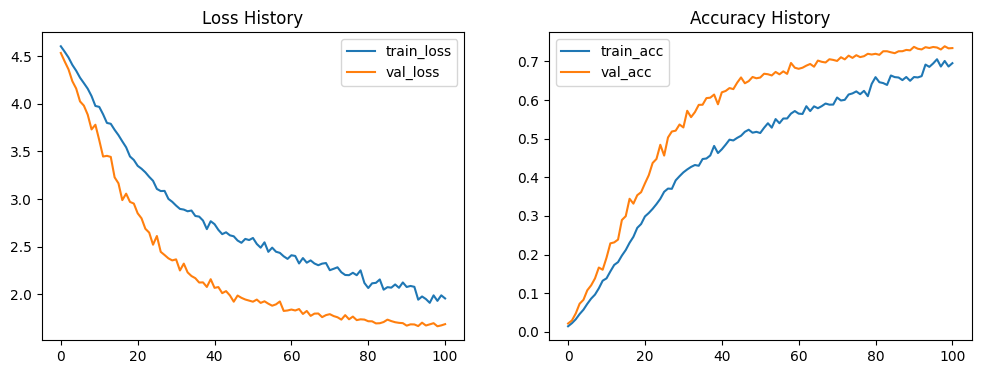

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train_acc')
plt.plot(val_accuracies, label='val_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

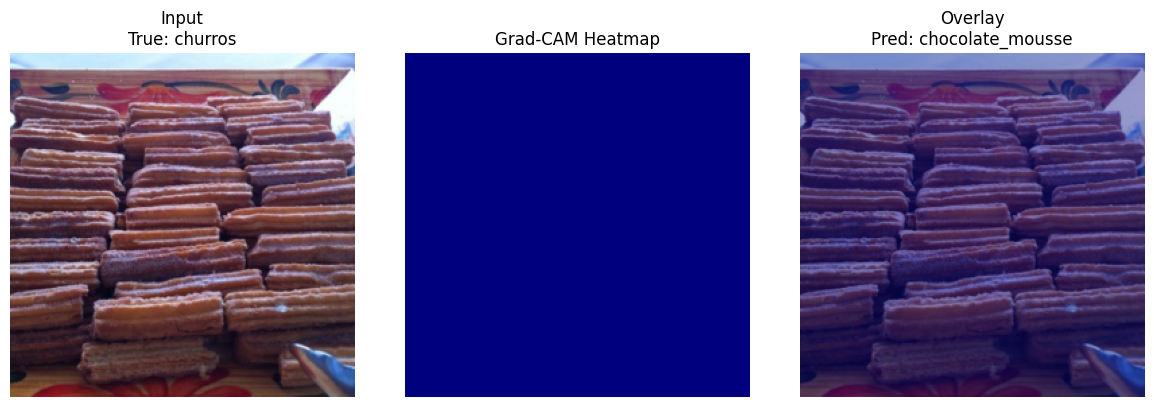

In [16]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

target_layer = model.features[-1].block[0]
activations = None
gradients = None

def forward_hook(module, inp, out):
    global activations
    activations = out.detach()

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

h1 = target_layer.register_forward_hook(forward_hook)
h2 = target_layer.register_full_backward_hook(backward_hook)

x, y = next(iter(test_loader))
x = x[:1].to(device)
y = y[:1].to(device)

out = model(x)
pred_idx = out.argmax(dim=1).item()

model.zero_grad(set_to_none=True)
score = out[0, pred_idx]
score.backward()

# Grad-CAM
weights = gradients.mean(dim=(2, 3), keepdim=True)
cam = torch.relu((weights * activations).sum(dim=1, keepdim=True))
cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
cam = cam.squeeze().cpu()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# Denormalisieren
mean = torch.tensor(stats[0]).view(3, 1, 1)
std = torch.tensor(stats[1]).view(3, 1, 1)
img = x[0].detach().cpu() * std + mean
img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()

true_idx = y.item()
true_label = test_dataset.classes[true_idx]
pred_label = test_dataset.classes[pred_idx]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f'Input\nTrue: {true_label}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam.numpy(), cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam.numpy(), cmap='jet', alpha=0.4)
plt.title(f'Overlay\nPred: {pred_label}')
plt.axis('off')

plt.tight_layout()
plt.show()

h1.remove()
h2.remove()